# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [1]:
import copy
import logging
import time
from itertools import combinations

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
from matplotlib import cm


## 1. Load & Crop Data

In [2]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0
print(initial_params)

current_pA = initial_params["I"]

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=current_pA,
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

SPIKE_PEAK_MV = 35.0
for st in sim_init.spike_times:
    idx = int(st / dt_ms)
    if 0 <= idx < len(sim_init.voltage):
        sim_init.voltage[idx] = SPIKE_PEAK_MV

T = np.append(T, T[-1] + dt_ms)
print(len(T))

INFO:2026-04-26 21:46:19,401:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


{'C_m': 200.0, 'g_L': 12.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 300.0, 'a': 2.0, 'b': 60.0, 'I': 500.0}
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
4001


## 2. Setup Cell & Loss Function

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 0.0000
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 200.0, 'g

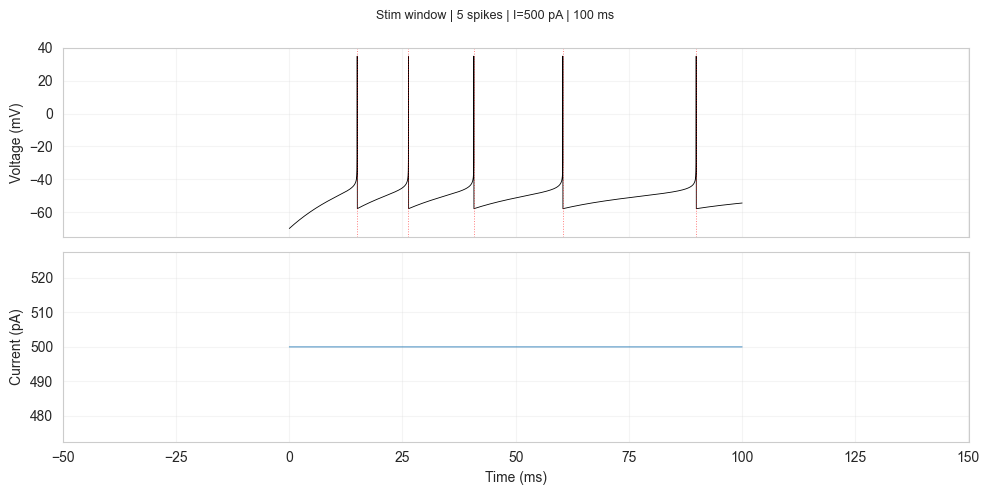

In [3]:
from ADoptEX.loss import (
    extract_experimental_features,
    GuarinoLossConfig,
    make_guarino_loss_fn, MSELossConfig, make_mse_loss_fn,
)

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

trace_stim_window_plot(TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"]))

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]),
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = len(sim_init.voltage)

loss_name = 'MSE'
loss_fn = make_mse_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=dt_ms,
    exp_voltage=target_voltage,
    stim_end_index=stim_end_index,
    loss_config=MSELossConfig(normalize=False, clamp_threshold=None, spike_peak_mv=SPIKE_PEAK_MV),
)

# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [4]:
GRID_SIZE = 10  # 20x20 per pair; 21 pairs * 400 = 8400 simulations

pairs = list(combinations(range(N_PARAMS), 2))
print(f"{len(pairs)} parameter pairs, {GRID_SIZE}x{GRID_SIZE} grid each")
print(f"Total simulations: {len(pairs) * GRID_SIZE**2}")

28 parameter pairs, 10x10 grid each
Total simulations: 2800


In [5]:
# Storage for all grids
grids = {}  # (i, j) -> {"X": ..., "Y": ..., "Z": ...}

t_start = time.time()

for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

    x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
    y_vals = np.linspace(by.min, by.max, GRID_SIZE)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    ix, iy = param_index[px], param_index[py]

    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                Z[r, c] = float(loss_fn(params_rc))
            except Exception:
                Z[r, c] = np.nan

    grids[(pi, pj)] = {"X": X, "Y": Y, "Z": Z}

    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"loss=[{np.nanmin(Z):.1f}, {np.nanmax(Z):.1f}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )

print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       loss=[33.9, 86.9]  elapsed=13s  ETA=351s
  [ 2/28] capacitance vs E_L       loss=[33.4, 337.2]  elapsed=29s  ETA=372s
  [ 3/28] capacitance vs v_T       loss=[34.3, 259.0]  elapsed=42s  ETA=351s
  [ 4/28] capacitance vs v_reset   loss=[30.5, 1073.9]  elapsed=56s  ETA=333s
  [ 5/28] capacitance vs tau_w     loss=[39.4, 98.6]  elapsed=69s  ETA=316s
  [ 6/28] capacitance vs a         loss=[35.3, 65.6]  elapsed=82s  ETA=302s
  [ 7/28] capacitance vs b         loss=[36.9, 457.8]  elapsed=96s  ETA=289s
  [ 8/28]      g_L vs E_L       loss=[28.1, 537.7]  elapsed=110s  ETA=275s
  [ 9/28]      g_L vs v_T       loss=[31.4, 182.6]  elapsed=123s  ETA=261s
  [10/28]      g_L vs v_reset   loss=[33.2, 234.8]  elapsed=137s  ETA=247s
  [11/28]      g_L vs tau_w     loss=[25.1, 66.4]  elapsed=150s  ETA=232s
  [12/28]      g_L vs a         loss=[23.4, 64.1]  elapsed=164s  ETA=219s
  [13/28]      g_L vs b         loss=[24.9, 77.3]  elapsed=179s  ETA=206s
  [14/28]      E

## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

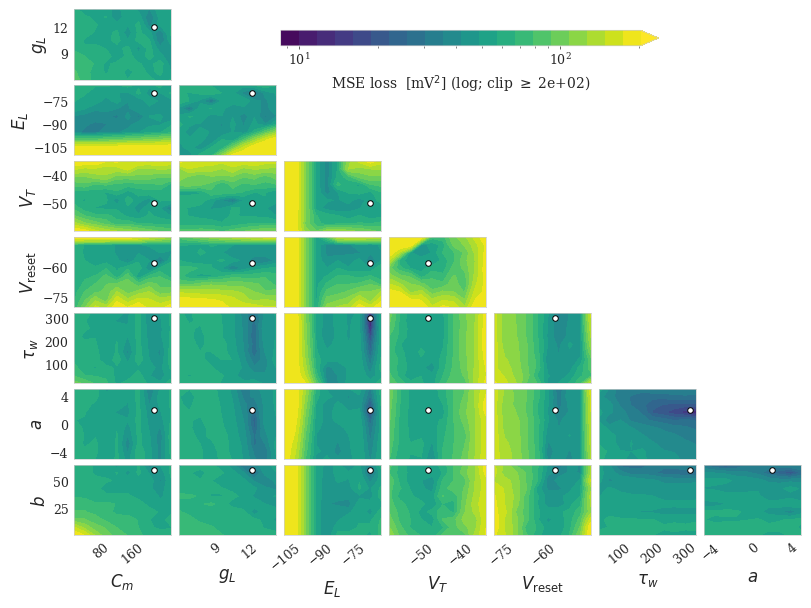

Saved to mse_loss_landscape_grid.pdf
Loss range across all pairs: [8.5, 1.28e+06]
Colorbar clip at 95th percentile: 203


In [6]:
#from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, MaxNLocator

PARAM_LABELS = {
    "capacitance": r"$C_m$",
    "g_L": r"$g_L$",
    "E_L": r"$E_L$",
    "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$",
    "v_reset": r"$V_\mathrm{reset}$",
    "tau_w": r"$\tau_w$",
    "a": r"$a$",
    "b": r"$b$",
}

# Units per loss function (missing entries render without a unit bracket)
LOSS_UNITS = {
    "MSE": r"mV$^2$",
}

def _map_name_to_initial(s):
    return "C_m" if s == "capacitance" else s

all_Z = np.concatenate([g["Z"].ravel() for g in grids.values()])
positive = all_Z[np.isfinite(all_Z) & (all_Z > 0)]
vmin = float(np.min(positive)) if positive.size else 1e-6
vmax_clip = float(np.nanpercentile(all_Z, 95))
vmax_clip = max(vmax_clip, vmin * 10)
vmax_true = float(np.nanmax(all_Z))
norm = LogNorm(vmin=vmin, vmax=vmax_clip)
levels = np.geomspace(vmin, vmax_clip, 21)

# Rendered at thesis print size: ~9x7 inches fits full-page landscape on A4
# (use \begin{sidewaysfigure}\includegraphics{...}\end{sidewaysfigure} in LaTeX).
# Fonts stay legible because LaTeX no longer rescales the figure.
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(
        N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False,
    )

    # Hide every cell first; lower triangle turns its cells back on below.
    # Diagonal cells stay hidden — the param name is already on the outer
    # row/column labels, so a diagonal label would be redundant.
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        Z_plot = np.clip(g["Z"], vmin, vmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], Z_plot,
            levels=levels, cmap="viridis", norm=norm, extend="max",
        )
        if mappable is None:
            mappable = cs

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            # Rotate bottom-row tick labels 40° to avoid overlap when the axis
            # shows 3-4 digit negative numbers (E_L, V_T, V_reset).
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        # Prune end-ticks so neighbouring cells' first/last labels don't kiss.
        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    # Extra bottom margin for the rotated tick labels in the bottom row.
    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    # Horizontal colorbar centered in the figure, vertically placed inside
    # row 1 of the upper triangle. Width ~4 cell-widths.
    pos_row = axes[1, 0].get_position()  # row 1, used only as y anchor
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=(hi - lo + 1)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)

    unit_str = LOSS_UNITS.get(loss_name)
    unit_bracket = f"  [{unit_str}]" if unit_str else ""
    cbar.set_label(
        rf"{loss_name} loss{unit_bracket} (log; clip $\geq$ {vmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_loss_landscape_grid.pdf")
    print(f"Loss range across all pairs: [{float(np.nanmin(all_Z)):.3g}, {vmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {vmax_clip:.3g}")


## 5. Gradient Landscape

Same grid as section 3, but at each point evaluates `jax.grad(loss_fn)` and
records the partial derivatives w.r.t. the two swept parameters. The triangle
grid below shows the gradient magnitude (log scale) with normalized quiver
arrows for direction.

In [7]:
grad_fn = jax.grad(loss_fn)

grad_grids = {}
t_start = time.time()
for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    g = grids[(pi, pj)]
    X, Y = g["X"], g["Y"]
    ix, iy = param_index[px], param_index[py]
    GX = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    GY = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                gd = grad_fn(params_rc)
                GX[r, c] = float(gd[ix][pxrc][0])
                GY[r, c] = float(gd[iy][pyrc][0])
            except Exception:
                pass
    MAG = np.sqrt(GX ** 2 + GY ** 2)
    grad_grids[(pi, pj)] = {"X": X, "Y": Y, "GX": GX, "GY": GY, "MAG": MAG}
    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"|grad|=[{np.nanmin(MAG):.2g}, {np.nanmax(MAG):.2g}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )
print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       |grad|=[9.4, 1.1e+09]  elapsed=55s  ETA=1498s
  [ 2/28] capacitance vs E_L       |grad|=[5.2, 7.8e+06]  elapsed=107s  ETA=1385s
  [ 3/28] capacitance vs v_T       |grad|=[48, 5.4e+07]  elapsed=161s  ETA=1342s
  [ 4/28] capacitance vs v_reset   |grad|=[3.9, 2.2e+07]  elapsed=220s  ETA=1321s
  [ 5/28] capacitance vs tau_w     |grad|=[0.24, 7.3e+08]  elapsed=279s  ETA=1284s
  [ 6/28] capacitance vs a         |grad|=[2.4, 5.6e+07]  elapsed=333s  ETA=1221s
  [ 7/28] capacitance vs b         |grad|=[9.3, 6.3e+06]  elapsed=390s  ETA=1170s
  [ 8/28]      g_L vs E_L       |grad|=[10, 1.6e+05]  elapsed=443s  ETA=1107s
  [ 9/28]      g_L vs v_T       |grad|=[68, 2.2e+07]  elapsed=498s  ETA=1051s
  [10/28]      g_L vs v_reset   |grad|=[7.6, 4.2e+06]  elapsed=552s  ETA=993s
  [11/28]      g_L vs tau_w     |grad|=[30, 2.7e+05]  elapsed=604s  ETA=934s
  [12/28]      g_L vs a         |grad|=[38, 8.2e+06]  elapsed=660s  ETA=880s
  [13/28]      g_L vs b         |grad|=

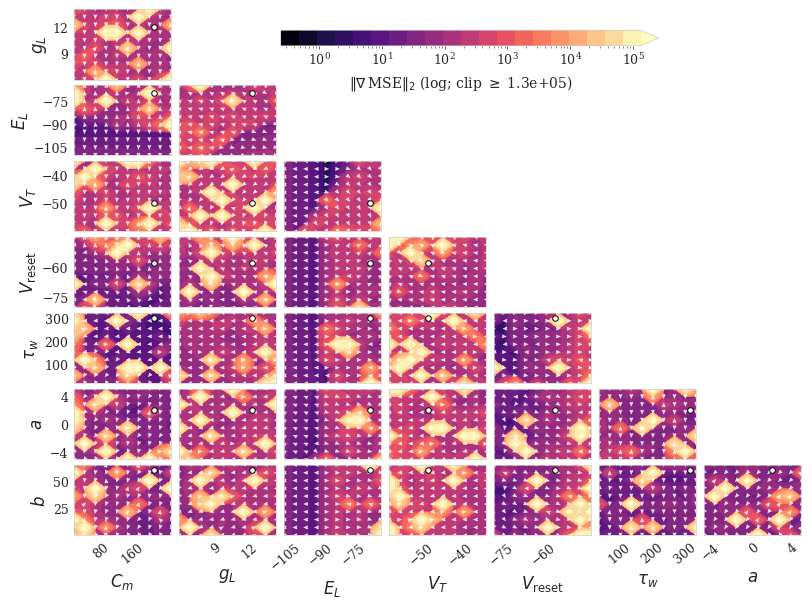

Saved to mse_grad_landscape_grid.pdf
Gradient magnitude range: [0.244, 2.24e+32]
Colorbar clip at 95th percentile: 1.32e+05


In [8]:
all_M = np.concatenate([g["MAG"].ravel() for g in grad_grids.values()])
positive_M = all_M[np.isfinite(all_M) & (all_M > 0)]
gmin = float(np.min(positive_M)) if positive_M.size else 1e-12
gmax_clip = float(np.nanpercentile(all_M, 95))
gmax_clip = max(gmax_clip, gmin * 10)
gmax_true = float(np.nanmax(all_M))
gnorm = LogNorm(vmin=gmin, vmax=gmax_clip)
glevels = np.geomspace(gmin, gmax_clip, 21)

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False)
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grad_grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        M = np.clip(g["MAG"], gmin, gmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], M,
            levels=glevels, cmap="magma", norm=gnorm, extend="max",
        )
        if mappable is None:
            mappable = cs

        step = max(1, GRID_SIZE // 6)
        Xs = g["X"][::step, ::step]
        Ys = g["Y"][::step, ::step]
        GXs = g["GX"][::step, ::step]
        GYs = g["GY"][::step, ::step]
        Ms = np.sqrt(GXs ** 2 + GYs ** 2)
        denom = np.where(Ms > 0, Ms, 1.0)
        U = GXs / denom
        V = GYs / denom
        ax.quiver(
            Xs, Ys, U, V,
            color="white", alpha=0.85, pivot="middle",
            scale=22, width=0.012, headwidth=3.5, headlength=4,
        )

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    pos_row = axes[1, 0].get_position()
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(gmin)))
    hi = int(np.ceil(np.log10(gmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=(hi - lo + 1)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)
    cbar.set_label(
        rf"$\|\nabla\,${loss_name}$\|_2$ (log; clip $\geq$ {gmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_grad_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_grad_landscape_grid.pdf")
    print(f"Gradient magnitude range: [{float(np.nanmin(all_M)):.3g}, {gmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {gmax_clip:.3g}")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

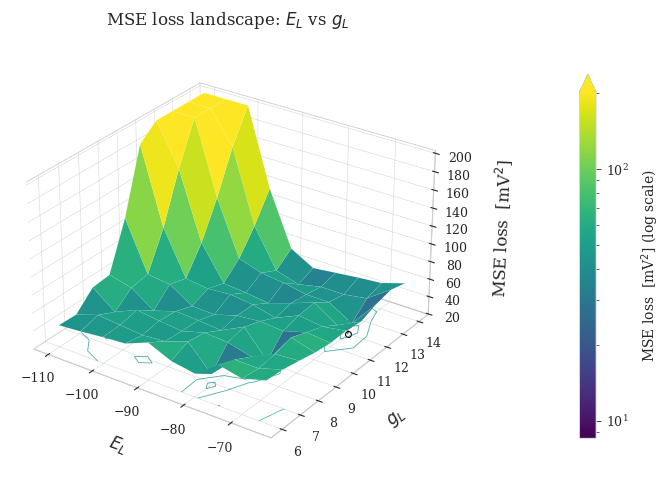

Saved to mse_loss_landscape_3d_E_L_g_L.pdf


In [9]:
# Pick which parameter pair to plot in 3D.
# Accepts either the display name ("C_m") or the internal name ("capacitance").
x_param = "E_L"
y_param = "g_L"

_ALIAS = {"C_m": "capacitance"}
x_key = _ALIAS.get(x_param, x_param)
y_key = _ALIAS.get(y_param, y_param)

if x_key not in PARAM_NAMES:
    raise KeyError(f"Unknown x param {x_param!r}; available: {PARAM_NAMES}")
if y_key not in PARAM_NAMES:
    raise KeyError(f"Unknown y param {y_param!r}; available: {PARAM_NAMES}")
if x_key == y_key:
    raise ValueError("x_param and y_param must differ")

pi, pj = PARAM_NAMES.index(x_key), PARAM_NAMES.index(y_key)

# `grids` only stores pairs with the first index < second (from combinations()).
# If the user picked the reversed order, fetch the stored grid and transpose so
# that the plotted X axis corresponds to x_param.
if (pi, pj) in grids:
    g = grids[(pi, pj)]
    X, Y, Z = g["X"], g["Y"], g["Z"]
else:
    g = grids[(pj, pi)]
    X, Y, Z = g["Y"].T, g["X"].T, g["Z"].T

xlabel = PARAM_LABELS[x_key]
ylabel = PARAM_LABELS[y_key]

# Clip to the same range used in the triangle grid so the 3D surface uses the
# same perceptual scale as the overview figure.
Z_plot = np.clip(Z, vmin, vmax_clip)
log_norm = LogNorm(vmin=vmin, vmax=vmax_clip)
facecolors = cm.viridis(log_norm(Z_plot))

# Default-parameter anchor: the minimum visible on the actual grid.
x0 = initial_params[_map_name_to_initial(x_key)]
y0 = initial_params[_map_name_to_initial(y_key)]

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
}):
    fig = plt.figure(figsize=(7.0, 5.5))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X,
        Y,
        Z_plot,
        facecolors=facecolors,
        rstride=1,
        cstride=1,
        linewidth=0.15,
        edgecolor=(1, 1, 1, 0.25),
        antialiased=True,
        shade=False,
    )

    # Contour projection on the floor, matching the surface's log color scale.
    z_floor = float(np.nanmin(Z_plot)) - 0.05 * (
        float(np.nanmax(Z_plot)) - float(np.nanmin(Z_plot))
    )
    ax.set_zlim(z_floor, float(np.nanmax(Z_plot)))
    contour_levels = np.geomspace(vmin, vmax_clip, 12)
    ax.contour(
        X,
        Y,
        Z_plot,
        levels=contour_levels,
        zdir="z",
        offset=z_floor,
        cmap="viridis",
        norm=log_norm,
        linewidths=0.6,
        alpha=0.8,
    )

    # Drop a thin marker line from the default parameters down to the floor.
    try:
        from scipy.interpolate import RegularGridInterpolator
        interp = RegularGridInterpolator(
            (Y[:, 0], X[0, :]), Z_plot, bounds_error=False, fill_value=np.nan
        )
        z0 = float(interp([[y0, x0]])[0])
        if np.isfinite(z0):
            ax.plot(
                [x0, x0], [y0, y0], [z_floor, z0],
                color="black", linewidth=0.8, alpha=0.7,
            )
            ax.scatter(
                [x0], [y0], [z0],
                s=28, facecolor="white", edgecolor="black", linewidth=0.8, zorder=5,
            )
    except Exception:
        pass
    ax.scatter(
        [x0], [y0], [z_floor],
        s=18, facecolor="white", edgecolor="black", linewidth=0.8, zorder=5,
    )

    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_zlabel(rf"{loss_name} loss  [mV$^2$]", labelpad=8)

    # Clean pane backgrounds — white panes, subtle grid, thin spines.
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor((0.6, 0.6, 0.6, 0.6))
        axis.pane.set_linewidth(0.6)
        axis._axinfo["grid"].update({"linewidth": 0.4, "color": (0.8, 0.8, 0.8, 0.8)})

    ax.tick_params(axis="both", which="major", pad=2, length=2.5, width=0.6)
    ax.view_init(elev=28, azim=-55)
    ax.set_box_aspect((1.0, 1.0, 0.65))

    # Colorbar anchored on the right with log-decade ticks, matching fig. 4.
    mappable = cm.ScalarMappable(norm=log_norm, cmap="viridis")
    mappable.set_array(Z_plot)
    cbar = fig.colorbar(
        mappable, ax=ax, shrink=0.7, pad=0.2, aspect=22, extend="max"
    )
    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=(hi - lo + 1)))
    cbar.ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(which="major", labelsize=9, length=3.5, width=0.6)
    cbar.ax.tick_params(which="minor", length=2.0, width=0.5)
    cbar.outline.set_linewidth(0.6)
    cbar.set_label(rf"{loss_name} loss  [mV$^2$] (log scale)", fontsize=10, labelpad=8)

    ax.set_title(f"{loss_name} loss landscape: {xlabel} vs {ylabel}", pad=10)

    fig.tight_layout()
    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_3d_{x_key}_{y_key}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print(
        f"Saved to {loss_name.lower()}_loss_landscape_3d_{x_key}_{y_key}.pdf"
    )
